In [1]:
# import libraries

import numpy as np
import pandas as pd
import geopandas as gpd

import json

import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import leafmap.maplibregl as leafmap

import os

Import files

In [2]:
# Load total pop
total_pop_folder = "Population Data"
pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_age_breakdown.parquet"))

# Load student pop
student_pop_gdf = gpd.read_parquet(os.path.join(total_pop_folder, "swk_1km_2020_population_stu_breakdown.parquet"))

# Load school pop
school_folder = "School Data"
school_gdf = gpd.read_parquet(os.path.join(school_folder, "swk_list_of_schools_2025.parquet"))

# Load combined routes
routes_folder = "OSRM Routes to Nearest School"
secondary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "secondary_combined_routes.parquet"))
primary_combined_routes_gdf = gpd.read_parquet(os.path.join(routes_folder, "primary_combined_routes.parquet"))

# Load aggregated data
aggregated_data_folder = "Aggregated Data"
district_time_stats_df = pd.read_csv(os.path.join(aggregated_data_folder,"district_summary_statistics_time_min.csv"))

# Boundaries
boundary_folder = "Geographic Boundaries"
swk_districts_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_districts.geojson")) # District boundaries
swk_parlimen_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_parliament.geojson")) # Parlimen boundaries
swk_dun_gdf = gpd.read_file(os.path.join(boundary_folder, "sarawak_dun.geojson")) # DUN boundaries

In [3]:
# Create total, primary and secondary population gdfs
total_pop_gdf = pop_gdf.copy()[["id","total_pop","x","y","geometry"]]
primary_pop_gdf = student_pop_gdf.copy()[["id","primary_school_students","x","y","geometry"]]
secondary_pop_gdf = student_pop_gdf.copy()[["id","secondary_school_students","x","y","geometry"]]

# Round numbders
total_pop_gdf["total_pop"] = total_pop_gdf["total_pop"].round(0).astype(int)
primary_pop_gdf["primary_school_students"] = primary_pop_gdf["primary_school_students"].round(0).astype(int)
secondary_pop_gdf["secondary_school_students"] = secondary_pop_gdf["secondary_school_students"].round(0).astype(int)

# Rename columns
total_pop_gdf = total_pop_gdf.rename(columns={"id":"pop_id","total_pop":"total_population"})
primary_pop_gdf = primary_pop_gdf.rename(columns={"id":"pop_id"})
secondary_pop_gdf = secondary_pop_gdf.rename(columns={"id":"pop_id"})

In [4]:
# Clean routes data
def clean_combined_routes_gdf(combined_routes_gdf):
    # Remove columns
    combined_routes_gdf = combined_routes_gdf.drop(columns=["euclidean_km"])
    
    # Rename columns
    combined_routes_gdf = combined_routes_gdf.rename(columns={
        "combined_route": "travel_mode",
        "osrm_km": "dist_km",
        "osrm_min": "time_min"
    })
    
    # Round numbers
    combined_routes_gdf["dist_km"] = combined_routes_gdf["dist_km"].round(1)
    combined_routes_gdf["time_min"] = combined_routes_gdf["time_min"].round(0)
    return combined_routes_gdf

secondary_combined_routes_gdf = clean_combined_routes_gdf(secondary_combined_routes_gdf)
primary_combined_routes_gdf = clean_combined_routes_gdf(primary_combined_routes_gdf)

In [5]:
# Create primary and school gdf
primary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Primary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]
secondary_school_gdf = school_gdf.copy()[school_gdf["primary_secondary"]=="Secondary"][["id","nama_sekolah","bil_murid","bil_guru","geometry"]]

# Rename columns
primary_school_gdf = primary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})
secondary_school_gdf = secondary_school_gdf.rename(columns={"id":"school_id","nama_sekolah":"school_name","bil_murid":"num_students","bil_guru":"num_teachers"})

In [6]:
# merge population gdf with combined routes gdf
secondary_pop_routes_gdf = secondary_pop_gdf[["pop_id","secondary_school_students"]].merge(
    secondary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

primary_pop_routes_gdf = primary_pop_gdf[["pop_id","primary_school_students"]].merge(
    primary_combined_routes_gdf,
    on="pop_id",
    how="left"
)

In [7]:
# Clean boundaries data

# Districts
swk_districts_gdf = swk_districts_gdf[["name","geometry"]].rename(columns={"name":"district"})

# DUNs
swk_dun_gdf = swk_dun_gdf[["dun","geometry"]]
swk_parlimen_gdf = swk_parlimen_gdf[["parlimen","geometry"]]

Output file paths

In [8]:
output_folder_charts = "Interactive Charts"
output_folder_maps = "Interactive Maps"

Change in median and IQR across districts

In [9]:
# INTERACTIVE CHART

# -------- Output file name --------
output_file_path = os.path.join(output_folder_charts,"district_median_iqr_time_plot.html")

# -------- Prepare data --------
df = district_time_stats_df.copy()
df = df[df["district"] != "Sarawak"]  # exclude Sarawak row

# -------- Population sizes for bubbles --------
primary_sizes = df["primary_school_students"] / df["primary_school_students"].max() * 50
secondary_sizes = df["secondary_school_students"] / df["secondary_school_students"].max() * 50

# -------- Sarawak reference lines --------
swk = district_time_stats_df[district_time_stats_df["district"] == "Sarawak"].iloc[0]

swk_p_med = swk["primary_median"]
swk_p_iqr = swk["primary_iqr"]

swk_s_med = swk["secondary_median"]
swk_s_iqr = swk["secondary_iqr"]

# ----------------------------------------------------
# Create subplot layout (two rows)
# ----------------------------------------------------
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Primary School Accessibility", "Secondary School Accessibility"),
    vertical_spacing=0.15
)

# ----------------------------------------------------
# Primary scatter (top)
# ----------------------------------------------------
fig.add_trace(
    go.Scatter(
        x=df["primary_median"],
        y=df["primary_iqr"],
        mode="markers+text",
        marker=dict(
            size=primary_sizes,
            color="royalblue",
            opacity=0.75,
            line=dict(width=1, color="darkblue")
        ),
        text=df["district"],
        textposition="top center",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Median: %{x:.1f} min<br>"
            "IQR: %{y:.1f} min<br>"
            "Primary students: %{customdata}<extra></extra>"
        ),
        customdata=df["primary_school_students"],
        name="Primary"
    ),
    row=1, col=1
)

# Reference lines — primary
fig.add_hline(y=swk_p_iqr, line=dict(color="grey", dash="dash"), row=1, col=1)
fig.add_vline(x=swk_p_med, line=dict(color="grey", dash="dash"), row=1, col=1)

# ----------------------------------------------------
# Secondary scatter (bottom)
# ----------------------------------------------------
fig.add_trace(
    go.Scatter(
        x=df["secondary_median"],
        y=df["secondary_iqr"],
        mode="markers+text",
        marker=dict(
            size=secondary_sizes,
            color="darkorange",
            opacity=0.75,
            line=dict(width=1, color="brown")
        ),
        text=df["district"],
        textposition="top center",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Median: %{x:.1f} min<br>"
            "IQR: %{y:.1f} min<br>"
            "Secondary students: %{customdata}<extra></extra>"
        ),
        customdata=df["secondary_school_students"],
        name="Secondary"
    ),
    row=2, col=1
)

# Reference lines — secondary
fig.add_hline(y=swk_s_iqr, line=dict(color="grey", dash="dash"), row=2, col=1)
fig.add_vline(x=swk_s_med, line=dict(color="grey", dash="dash"), row=2, col=1)

# ----------------------------------------------------
# Axes and layout
# ----------------------------------------------------
max_x = max(df["secondary_median"]) * 1.1
max_y = max(df["secondary_iqr"]) * 1.1

fig.update_xaxes(title_text="Median Travel Time (minutes)", range=[0, max_x], row=1, col=1)
fig.update_yaxes(title_text="Interquartile Range (minutes)", range=[0, max_y], row=1, col=1)

fig.update_xaxes(title_text="Median Travel Time (minutes)", range=[0, max_x], row=2, col=1)
fig.update_yaxes(title_text="Interquartile Range (minutes)", range=[0, max_y], row=2, col=1)

fig.update_layout(
    title="Primary vs Secondary School Accessibility (Median vs IQR)",
    template="plotly_white",
    width=900,
    height=1100,
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.12,
        xanchor="center", x=0.5
    )
)

# ----------------------------------------------------
# Custom Legend (Population + Primary/Secondary + Reference Lines)
# ----------------------------------------------------

# Less students (small grey)
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(size=8, color="lightgrey", line=dict(color="grey", width=1)),
    name="Less students"
))

# More students (large grey)
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode="markers",
    marker=dict(size=20, color="lightgrey", line=dict(color="grey", width=1)),
    name="More students"
))

# Sarawak-wide median & IQR (dashed reference)
fig.add_trace(go.Scatter(
    x=[None, None],
    y=[None, None],
    mode="lines",
    line=dict(color="grey", dash="dash"),
    name="Sarawak-wide median and IQR"
))


fig.show()

# Save ready for embedding
fig.write_html(output_file_path, include_plotlyjs="cdn")

Static plot of median and IQR

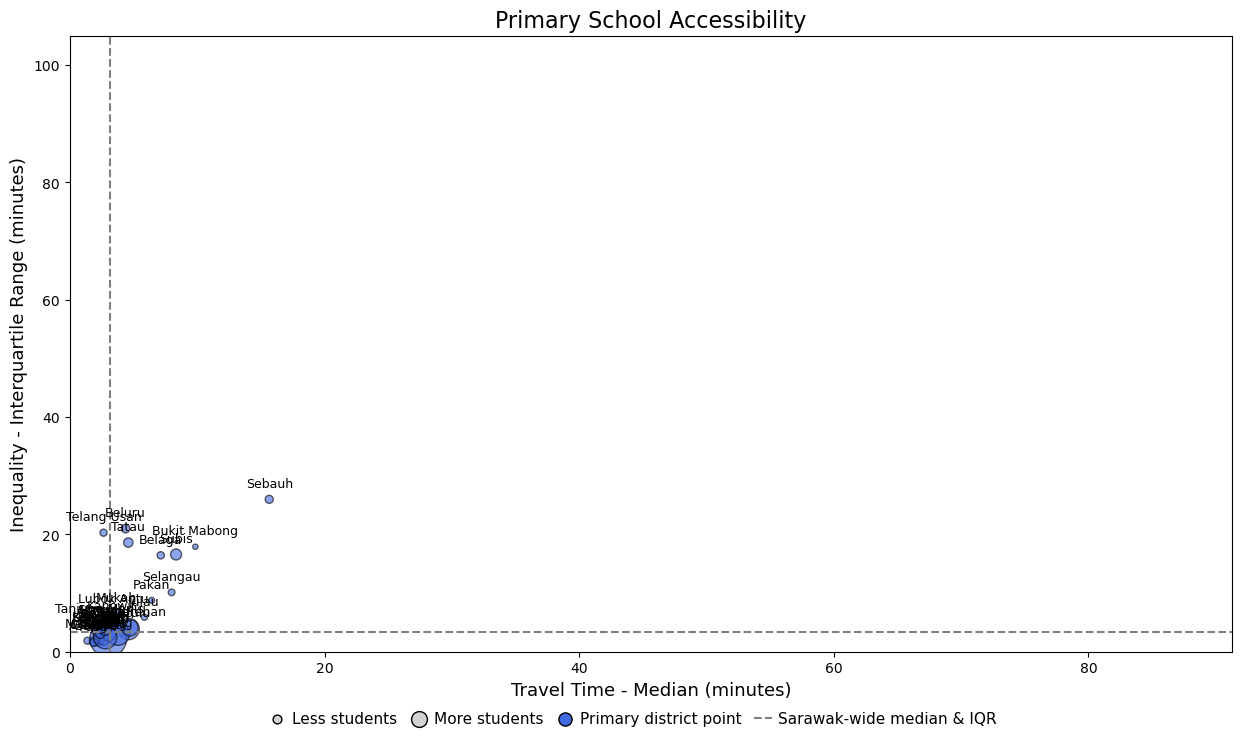

In [10]:
df = district_time_stats_df.copy()

# --- Sarawak thresholds ---
swk_primary_median = df.loc[df["district"] == "Sarawak", "primary_median"].iloc[0]
swk_primary_iqr = df.loc[df["district"] == "Sarawak", "primary_iqr"].iloc[0]

df_plot = df[df["district"] != "Sarawak"]

# Bubble sizes
sizes_primary = df_plot["primary_school_students"] / df_plot["primary_school_students"].max() * 700

# Shared axis limits (same across both plots)
max_x = max(df_plot["primary_median"].max(), df_plot["secondary_median"].max()) * 1.15
max_y = max(df_plot["primary_iqr"].max(), df_plot["secondary_iqr"].max()) * 1.15

fig, ax = plt.subplots(figsize=(15, 8))

# ======================================================
# Scatter plot
# ======================================================
ax.scatter(df_plot["primary_median"], df_plot["primary_iqr"],
           s=sizes_primary, alpha=0.6, edgecolor="black", color="royalblue")

# Reference lines
ax.axvline(swk_primary_median, color="grey", linestyle="--")
ax.axhline(swk_primary_iqr, color="grey", linestyle="--")

# Labels
label_offset = max_y * 0.015
for _, row in df_plot.iterrows():
    ax.text(row["primary_median"],
            row["primary_iqr"] + label_offset,
            row["district"],
            fontsize=9, ha="center", va="bottom")

# Axes
ax.set_xlim(0, max_x)
ax.set_ylim(0, max_y)
ax.set_title("Primary School Accessibility", fontsize=16)
ax.set_xlabel("Travel Time - Median (minutes)", fontsize=13)
ax.set_ylabel("Inequality - Interquartile Range (minutes)", fontsize=13)

# ======================================================
# Tighter Legend at bottom
# ======================================================

small_pop = plt.scatter([], [], s=40, edgecolor="black", color="lightgrey")
large_pop = plt.scatter([], [], s=130, edgecolor="black", color="lightgrey")
primary_marker = plt.scatter([], [], s=90, edgecolor="black", color="royalblue")
ref_line = plt.Line2D([0], [0], color="grey", linestyle="--", linewidth=1.5)

fig.legend(
    [small_pop, large_pop, primary_marker, ref_line],
    ["Less students", "More students", "Primary district point", "Sarawak-wide median & IQR"],
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0),
    handlelength=1.2,       # shorter handles
    handletextpad=0.4,      # tighter text spacing
    columnspacing=0.8       # tighter column spacing
)

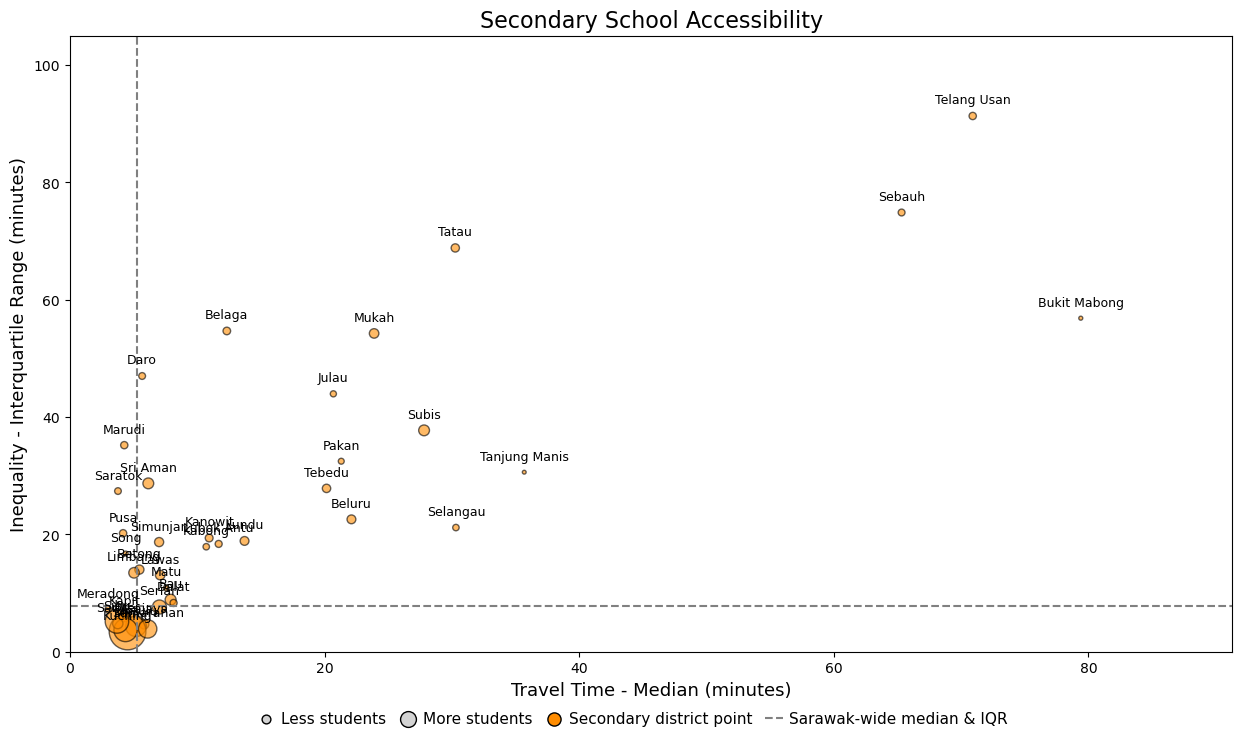

In [11]:

df = district_time_stats_df.copy()

# --- Sarawak thresholds ---
swk_secondary_median = df.loc[df["district"] == "Sarawak", "secondary_median"].iloc[0]
swk_secondary_iqr = df.loc[df["district"] == "Sarawak", "secondary_iqr"].iloc[0]

df_plot = df[df["district"] != "Sarawak"]

# Bubble sizes
sizes_secondary = df_plot["secondary_school_students"] / df_plot["secondary_school_students"].max() * 700

# Shared limits
max_x = max(df_plot["primary_median"].max(), df_plot["secondary_median"].max()) * 1.15
max_y = max(df_plot["primary_iqr"].max(), df_plot["secondary_iqr"].max()) * 1.15

fig, ax = plt.subplots(figsize=(15, 8))

# ======================================================
# Scatter plot
# ======================================================
ax.scatter(df_plot["secondary_median"], df_plot["secondary_iqr"],
           s=sizes_secondary, alpha=0.6, edgecolor="black", color="darkorange")

# Reference lines
ax.axvline(swk_secondary_median, color="grey", linestyle="--")
ax.axhline(swk_secondary_iqr, color="grey", linestyle="--")

# Labels
label_offset = max_y * 0.015
for _, row in df_plot.iterrows():
    ax.text(row["secondary_median"],
            row["secondary_iqr"] + label_offset,
            row["district"],
            fontsize=9, ha="center", va="bottom")

# Axes
ax.set_xlim(0, max_x)
ax.set_ylim(0, max_y)
ax.set_title("Secondary School Accessibility", fontsize=16)
ax.set_xlabel("Travel Time - Median (minutes)", fontsize=13)
ax.set_ylabel("Inequality - Interquartile Range (minutes)", fontsize=13)

# ======================================================
# Tighter Legend at bottom
# ======================================================

small_pop = plt.scatter([], [], s=40, edgecolor="black", color="lightgrey")
large_pop = plt.scatter([], [], s=130, edgecolor="black", color="lightgrey")
secondary_marker = plt.scatter([], [], s=90, edgecolor="black", color="darkorange")
ref_line = plt.Line2D([0], [0], color="grey", linestyle="--", linewidth=1.5)

fig.legend(
    [small_pop, large_pop, secondary_marker, ref_line],
    ["Less students", "More students", "Secondary district point", "Sarawak-wide median & IQR"],
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 0),
    handlelength=1.2,       # shorter handles
    handletextpad=0.4,      # tighter text spacing
    columnspacing=0.8       # tighter column spacing
)


Create a interactive map showing the increases in travel times between primary and secondary schools

In [12]:
# Merge secondary routes and primary routes

# Filter
secondary_combined_routes_gdf_filtered = secondary_combined_routes_gdf[["pop_id","pop_x","pop_y","time_min","school_name"]]
primary_combined_routes_gdf_filtered = primary_combined_routes_gdf[["pop_id","pop_x","pop_y","time_min","school_name"]]

# Rename
secondary_combined_routes_gdf_filtered = secondary_combined_routes_gdf_filtered.rename(columns={"time_min":"time_min_sec","school_name":"sec_school"})
primary_combined_routes_gdf_filtered = primary_combined_routes_gdf_filtered.rename(columns={"time_min":"time_min_pri","school_name":"pri_school"})

# Merge dataframes
sec_pri_gdf = primary_combined_routes_gdf_filtered.merge(
    secondary_combined_routes_gdf_filtered,
    on=["pop_id","pop_x","pop_y"],
    how="outer"
)

# Calculate the difference
sec_pri_gdf["time_min_diff"] = sec_pri_gdf["time_min_sec"] - sec_pri_gdf["time_min_pri"]

In [13]:
# Clean and sort the merged table
sec_pri_gdf = sec_pri_gdf.merge(total_pop_gdf[["pop_id","total_population"]], on="pop_id", how="left").merge(primary_pop_gdf[["pop_id","primary_school_students"]], on="pop_id", how="left").merge(secondary_pop_gdf[["pop_id","secondary_school_students"]], on="pop_id", how="left")

# Sort columns
sec_pri_gdf = sec_pri_gdf[["pop_id","pop_x","pop_y","total_population","primary_school_students","secondary_school_students","time_min_diff","time_min_pri","time_min_sec","pri_school","sec_school"]]

In [14]:
# Simplify the primary and secondary school routes

# Filter the primary and secondary school routes
primary_combined_routes_gdf_filtered = primary_combined_routes_gdf[["pop_id","travel_mode","geometry"]]
secondary_combined_routes_gdf_filtered = secondary_combined_routes_gdf[["pop_id","travel_mode","geometry"]]

# Simplify geometry
tolerance = 0.00001  # ~1 metre, adjust if needed

primary_combined_routes_gdf_filtered["geometry"] = (
    primary_combined_routes_gdf_filtered["geometry"]
    .simplify(tolerance, preserve_topology=True)
)

secondary_combined_routes_gdf_filtered["geometry"] = (
    secondary_combined_routes_gdf_filtered["geometry"]
    .simplify(tolerance, preserve_topology=True)
)


In [15]:
# Create interactive map

# -----------------------------
# 0. Define output folders
# -----------------------------

base_output_folder = output_folder_maps   # your original output folder
assets_folder = os.path.join(base_output_folder, "assets")
os.makedirs(assets_folder, exist_ok=True)

# HTML output file
output_path = os.path.join(
    base_output_folder,
    "swk_travel_time_change_interactive_map.html"
)

# -----------------------------
# 1. Create gdfs for layers
# -----------------------------

sec_pri_gdf = gpd.GeoDataFrame(
    sec_pri_gdf, geometry=gpd.points_from_xy(sec_pri_gdf["pop_x"],sec_pri_gdf["pop_y"]), crs="EPSG:4326")

# -----------------------------
# 2. Build viridis colour scale & line color based on travel time
# -----------------------------

# define buckets
bins = [-np.inf, 0, 30, 60, 90, np.inf]
labels = [
    "< 0",
    "0 to 30",
    "30 to 60",
    "60 to 90",
    "> 90"
]

# Assign bucket category
sec_pri_gdf["bucket"] = pd.cut(
    sec_pri_gdf["time_min_diff"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Bucket colors
bucket_colours = {
    "< 0":       "#440154",  # purple
    "0 to 30":    "#3b528b",  # blue
    "30 to 60":     "#21918c",  # teal
    "60 to 90":   "#5ec962",  # green
    "> 90":        "#fce300",  # yellow
}

# Map to colours
sec_pri_gdf["colour"] = sec_pri_gdf["bucket"].map(bucket_colours)

# Convert to object
sec_pri_gdf["colour"] = sec_pri_gdf["colour"].astype("object")
 
# No routes at all → red
sec_pri_gdf.loc[(sec_pri_gdf["time_min_pri"].isna()) &
                (sec_pri_gdf["time_min_sec"].isna()),
                "colour"] = "#ff0000"       # Red

# Has primary route but no secondary route → orange
sec_pri_gdf.loc[(sec_pri_gdf["time_min_pri"].notna()) &
                (sec_pri_gdf["time_min_sec"].isna()),
                "colour"] = "#ff8800"       # Orange

# -----------------------------
# 3. Build colors for the combined routes
# -----------------------------

travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

# Primary school
primary_combined_routes_gdf_filtered["colour"] = (
    primary_combined_routes_gdf_filtered["travel_mode"]
    .map(travel_mode_dict)
    .astype("object")   
)

# Secondary school
secondary_combined_routes_gdf_filtered["colour"] = (
    secondary_combined_routes_gdf_filtered["travel_mode"]
    .map(travel_mode_dict)
    .astype("object")   
)

# -----------------------------
# 4. Build the interactive map
# -----------------------------

x = (sec_pri_gdf["pop_x"].max() + sec_pri_gdf["pop_x"].min()) / 2
y = (sec_pri_gdf["pop_y"].max() + sec_pri_gdf["pop_y"].min()) / 2

m = leafmap.Map(height="600px", center=[x, y], use_message_queue=True, style="street")

# Basemap
m.add_basemap("Esri.WorldImagery", before_id=m.first_symbol_layer_id, visible=False)
m.add_tile_layer(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Esri.WorldImagery (Basemap)",
    attribution="Esri World Imagery",
    visible=True
)

# -----------------------------
# 5. Create Population and Route Data Layers
# -----------------------------

# Plot the change in travel time
m.add_gdf(
    gdf=sec_pri_gdf,
    name="Change in Travel Time",
    layer_type="circle",
    paint={"circle-radius": 3, 
           "circle-color": ["get", "colour"]},
    visible=True
)

# Plot the secondary routes
m.add_gdf(
    gdf=secondary_combined_routes_gdf_filtered,
    name="Secondary School Routes",
    layer_type="line",
    paint={"line-color": ["get","colour"]},
    visible=True
)

# Plot the primary routes
m.add_gdf(
    gdf=primary_combined_routes_gdf_filtered,
    name="Primary School Routes",
    layer_type="line",
    paint={"line-color": ["get","colour"]}
)


# -----------------------------
# 6. Adminstrative Boundaries
# -----------------------------

# Adminstrative boundaries
m.add_gdf(
    gdf=swk_districts_gdf,
    name="District Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=True
)

m.add_gdf(
    gdf=swk_parlimen_gdf,
    name="Parlimen Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)

m.add_gdf(
    gdf=swk_dun_gdf,
    name="DUN Boundaries",
    layer_type="line",
    paint={"line-color": "#ffffffeb"},
    visible=False
)


# -----------------------------
# 7. Add school layers
# -----------------------------

# -- Primary Schools ---
image_pri = "Interactive Maps/assets/icons/college_blue.png"

primary_geojson = json.loads(primary_school_gdf.to_json())
source_pri = {"type": "geojson", "data": primary_geojson}

layer_pri = {
    "id": "Primary Schools",
    "type": "symbol",
    "source": "point_pri",
    "layout": {
        "icon-image": "pri_school",
        "icon-size": 0.08}
}

m.add_image("pri_school", image_pri)
m.add_source("point_pri", source_pri)
m.add_layer(layer_pri)
m.add_popup("Primary Schools")

# -- Secondary Schools ---
image_sec = "Interactive Maps/assets/icons/college_orange.png"

secondary_geojson = json.loads(secondary_school_gdf.to_json())
source_sec = {"type": "geojson", "data": secondary_geojson}

layer_sec = {
    "id": "Secondary Schools",
    "type": "symbol",
    "source": "point_sec",
    "layout": {
        "icon-image": "sec_school",
        "icon-size": 0.08}
}

m.add_image("sec_school", image_sec)
m.add_source("point_sec", source_sec)
m.add_layer(layer_sec)
m.add_popup("Secondary Schools")

# -----------------------------
# 8. Add legend
# -----------------------------

# Legend for travel time
legend_dict = {
    "< 0":                       "#440154",  # purple
    "0 to 30":                   "#3b528b",  # blue
    "30 to 60":                  "#21918c",  # teal
    "60 to 90":                  "#5ec962",  # green
    "> 90":                      "#fce300",  # yellow
    "Pri exists, sec no route":  "#ff8800",  # orange
    "Both pri and sec no route": "#ff0000",  # red
}

m.add_legend(
    title = "Change in Travel Time (mins)",
    legend_dict = legend_dict,
    position = "bottom-right"
)

# Legend for travel mode
travel_mode_dict = {
    "car":  "#000000eb",   # black
    "foot": "#6200ffeb",   # purple
    "boat": "#00318DFF"    # blue
}

m.add_legend(
    title = "Travel Mode",
    legend_dict = travel_mode_dict,
    position = "bottom-right"
)

# -----------------------------
# 9. Add map title / sources
# -----------------------------

m.add_text(
    "Change in Travel Time between Primary and Secondary School",
    position="top-left",
    font_size=12
)

# -----------------------------
# 10. Layer control
# -----------------------------

m.add_layer_control(
    layer_ids=[
        "Change in Travel Time",
        "Primary Schools",
        "Secondary Schools",
        "Primary School Routes",
        "Secondary School Routes",
        "District Boundaries",
        "Parlimen Boundaries",
        "DUN Boundaries",
        "Esri.WorldImagery (Basemap)"
    ],
    position="top-left"
)

# -----------------------------
# 11. Export HTML
# -----------------------------

m.to_html(
    output=output_path,
    title="Change in Travel Time between Primary and Secondary School",
    overwrite=True
)

m

Html(children=[<leafmap.maplibregl.Map object at 0x000001DB6DECD180>, Card(children=[Btn(children=[Icon(childr…

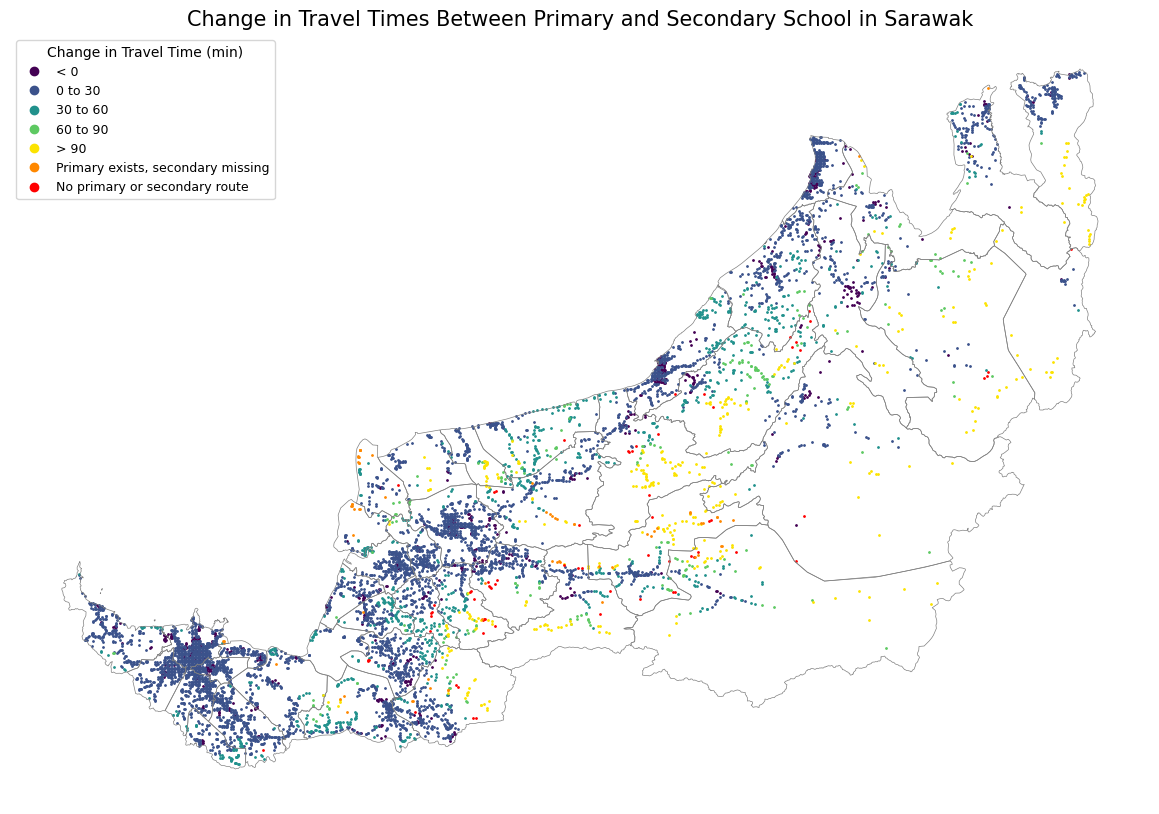

In [16]:
# Create static plot of the change in travel time
plt.figure(figsize=(16, 10))

bucket_colours = {
    "< 0":       "#440154",  # purple
    "0 to 30":    "#3b528b",  # blue
    "30 to 60":     "#21918c",  # teal
    "60 to 90":   "#5ec962",  # green
    "> 90":        "#fce300",  # yellow
}

# filter into different buckets
sec_pri_gdf_0 = sec_pri_gdf[sec_pri_gdf["time_min_diff"] < 0]
sec_pri_gdf_30 = sec_pri_gdf[(sec_pri_gdf["time_min_diff"] >= 0) & (sec_pri_gdf["time_min_diff"] < 30)]
sec_pri_gdf_60 = sec_pri_gdf[(sec_pri_gdf["time_min_diff"] >= 30) & (sec_pri_gdf["time_min_diff"] < 60)]
sec_pri_gdf_90 = sec_pri_gdf[(sec_pri_gdf["time_min_diff"] >= 60) & (sec_pri_gdf["time_min_diff"] < 90)]
sec_pri_gdf_m90 = sec_pri_gdf[(sec_pri_gdf["time_min_diff"] >= 90)]

sec_pri_gdf_both_nr = sec_pri_gdf[(sec_pri_gdf["time_min_sec"].isna()) & (sec_pri_gdf["time_min_pri"].isna())]
sec_pri_gdf_sec_nr = sec_pri_gdf[(sec_pri_gdf["time_min_sec"].isna()) & (sec_pri_gdf["time_min_pri"].notna())]

# Add district boundaries
swk_districts_gdf.boundary.plot(ax=plt.gca(), edgecolor='grey', linewidth=0.5)

# plot population points
plt.scatter(sec_pri_gdf_0["pop_x"],sec_pri_gdf_0["pop_y"],c="#440154",s=1)
plt.scatter(sec_pri_gdf_30["pop_x"],sec_pri_gdf_30["pop_y"],c="#3b528b",s=1)
plt.scatter(sec_pri_gdf_60["pop_x"],sec_pri_gdf_60["pop_y"],c="#21918c",s=1)
plt.scatter(sec_pri_gdf_90["pop_x"],sec_pri_gdf_90["pop_y"],c="#5ec962",s=1)
plt.scatter(sec_pri_gdf_m90["pop_x"],sec_pri_gdf_m90["pop_y"],c="#fce300",s=1)

plt.scatter(sec_pri_gdf_both_nr["pop_x"],sec_pri_gdf_both_nr["pop_y"],c="#ff0000",s=1)
plt.scatter(sec_pri_gdf_sec_nr["pop_x"],sec_pri_gdf_sec_nr["pop_y"],c="#ff8800",s=1)

# Add legend
legend_handles = [
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#440154", label="< 0"),
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#3b528b", label="0 to 30"),
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#21918c", label="30 to 60"),
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#5ec962", label="60 to 90"),
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#fce300", label="> 90"),

    # Missing-route categories
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#ff8800", label="Primary exists, secondary missing"),
    plt.Line2D([], [], marker='o', linestyle='none',
               markersize=6, color="#ff0000", label="No primary or secondary route"),
]

plt.legend(
    handles=legend_handles,
    title="Change in Travel Time (min)",
    loc="best",
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

# title
plt.title(f"Change in Travel Times Between Primary and Secondary School in Sarawak", fontsize=15)
plt.axis("off")
plt.show()
